In [18]:
import json
import requests
import shutil
import pandas as pd
import geopandas as gpd
import os
from google.protobuf.json_format import MessageToDict, MessageToJson
import google.protobuf
print(google.protobuf.__file__)
print(google.protobuf.__version__)
import gtfs_realtime_pb2
import _utils_ as utils

/Users/admin/Library/Mobile Documents/com~apple~CloudDocs/Coding/Smart Cities - Scripts/gtfs_env/lib/python3.9/site-packages/google/protobuf/__init__.py
6.31.0


## 1 - Descargar informacion estatica del sistema

Esplorar las columnas y tipos de datos

In [ ]:
# fuente = 'https://datosabiertos.bogota.gov.co/dataset/especificacion-gtfs-general-transport-feed-specification-sitp/resource/0885fac9-a7bb-490f-abe8-ddee3bbe9cf2'
directory = "GTFS_Durham_TXT"

routes = pd.read_csv(os.path.join(directory,"routes.txt"))
print(routes.shape)
routes.head()

(37, 9)


,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type,route_url,route_color,route_text_color
0,101,drt,101,Route 101,NaN,3,NaN,006633,ffffff
1,112,drt,112,Route 112,NaN,3,NaN,006633,ffffff
2,118,drt,118,Route 118,NaN,3,NaN,006633,ffffff
3,121,drt,121,Route 121,NaN,3,NaN,006633,ffffff
4,211,drt,211,Route 211,NaN,3,NaN,006633,ffffff


In [3]:
shapes = pd.read_csv(os.path.join(directory,"shapes.txt"))
print(shapes.shape)
shapes_layer = utils.df_to_geojson(shapes, "shape_pt_lat", "shape_pt_lon", geometry_type="LineString", output_file="geojson_layers/shapes.geojson", group_by="shape_id")
shapes.head()

(107250, 5)


,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled
0,100.0.1952649896_Timetable_-_2025-04_(v2),43.863580,-79.016129,0,0.000000
1,100.0.1952649896_Timetable_-_2025-04_(v2),43.863585,-79.016117,1,1.154939
2,100.0.1952649896_Timetable_-_2025-04_(v2),43.863481,-79.016070,2,13.351833
3,100.0.1952649896_Timetable_-_2025-04_(v2),43.863370,-79.016022,3,26.280491
4,100.0.1952649896_Timetable_-_2025-04_(v2),43.863113,-79.015909,4,56.259049


In [4]:
stops = pd.read_csv(os.path.join(directory,"stops.txt"))
print(stops.shape)
utils.df_to_geojson(stops, "stop_lat", "stop_lon", geometry_type="Point", output_file="geojson_layers/stops.geojson", group_by=None)
stops.head()

(1891, 13)


,stop_id,stop_code,stop_name,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,stop_timezone,wheelchair_boarding,preferred
0,10,10,Garden Northbound @ Bassett (South stop),NaN,43.903333,-78.941559,NaN,NaN,0,NaN,NaN,1,2
1,100,100,McQuay Northbound @ Dundas,NaN,43.875932,-78.961715,NaN,NaN,0,NaN,NaN,1,2
2,1000,1000,Glen Northbound @ Medina,NaN,43.872683,-78.855412,NaN,NaN,0,NaN,NaN,1,2
3,1001,1001,Northbound @ 825 Glen,NaN,43.875296,-78.856489,NaN,NaN,0,NaN,NaN,1,2
4,1002,1002,Malaga Westbound @ Oxford,NaN,43.875507,-78.858799,NaN,NaN,0,NaN,NaN,1,2


In [5]:
trips = pd.read_csv(os.path.join(directory,"trips.txt"))
print(trips.shape)
trips.head()

(3756, 9)


,route_id,service_id,trip_id,trip_headsign,direction_id,block_id,shape_id,direction_name,wheelchair_accessible
0,403,Weekday,100__401085_Timetable_-_2025-04_(v2),Oshawa Centre Terminal,0,401085_Timetable_-_2025-04_(v2),100.0.1046829277_Timetable_-_2025-04_(v2),Northbound,1
1,403,Weekday,101__401066_Timetable_-_2025-04_(v2),Oshawa Centre Terminal,0,401066_Timetable_-_2025-04_(v2),100.0.1046829277_Timetable_-_2025-04_(v2),Northbound,1
2,403,Weekday,102__401033_Timetable_-_2025-04_(v2),Oshawa Centre Terminal,0,401033_Timetable_-_2025-04_(v2),100.0.1046829277_Timetable_-_2025-04_(v2),Northbound,1
3,403,Weekday,103__401080_Timetable_-_2025-04_(v2),Oshawa Centre Terminal,0,401080_Timetable_-_2025-04_(v2),100.0.1046829277_Timetable_-_2025-04_(v2),Northbound,1
4,423,Weekday,1044__401003_Timetable_-_2025-04_(v2),Harmony Terminal,0,401003_Timetable_-_2025-04_(v2),100.0.1672883331_Timetable_-_2025-04_(v2),Northbound,1


In [6]:
stop_times = pd.read_csv(os.path.join(directory,"stop_times.txt"))
print(stop_times.shape)
stop_times.head()

(154976, 10)


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint
0,4042__461037_Timetable_-_2025-04_(v2),13:18:00,13:18:00,812,1,NaN,0,0,NaN,1
1,4042__461037_Timetable_-_2025-04_(v2),13:19:21,13:19:21,90038,2,NaN,0,0,NaN,0
2,4042__461037_Timetable_-_2025-04_(v2),13:20:08,13:20:08,94194,3,NaN,0,0,NaN,0
3,4042__461037_Timetable_-_2025-04_(v2),13:20:25,13:20:25,90080,4,NaN,0,0,NaN,0
4,4042__461037_Timetable_-_2025-04_(v2),13:21:36,13:21:36,3135,5,NaN,0,0,NaN,0


## 2 - Union: Ejemplo con Paradas y Tiempos de Parada

In [7]:
print(stop_times.shape, stops.shape)
stops_times_merged = pd.merge(stop_times, stops)
print("Dimensiones de tabla unida", stops_times_merged.shape)
stops_times_merged.head()

(154976, 10) (1891, 13)
Dimensiones de tabla unida (154976, 22)


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,...,stop_desc,stop_lat,stop_lon,zone_id,stop_url,location_type,parent_station,stop_timezone,wheelchair_boarding,preferred
0,4042__461037_Timetable_-_2025-04_(v2),13:18:00,13:18:00,812,1,NaN,0,0,NaN,1,...,NaN,43.942102,-78.848752,NaN,NaN,0,NaN,NaN,1,1
1,4042__461037_Timetable_-_2025-04_(v2),13:19:21,13:19:21,90038,2,NaN,0,0,NaN,0,...,NaN,43.944594,-78.850769,NaN,NaN,0,NaN,NaN,1,2
2,4042__461037_Timetable_-_2025-04_(v2),13:20:08,13:20:08,94194,3,NaN,0,0,NaN,0,...,NaN,43.945712,-78.846137,NaN,NaN,0,NaN,NaN,2,2
3,4042__461037_Timetable_-_2025-04_(v2),13:20:25,13:20:25,90080,4,NaN,0,0,NaN,0,...,NaN,43.946125,-78.844471,NaN,NaN,0,NaN,NaN,1,2
4,4042__461037_Timetable_-_2025-04_(v2),13:21:36,13:21:36,3135,5,NaN,0,0,NaN,0,...,NaN,43.949878,-78.843025,NaN,NaN,0,NaN,NaN,2,2


# 3 - Información Dinámica con GET request

In [15]:

vehicle_positions_url = 'https://drtonline.durhamregiontransit.com/gtfsrealtime/VehiclePositions'
response = requests.get(vehicle_positions_url)

vehicle_positions = {}

feed = gtfs_realtime_pb2.FeedMessage()
feed.ParseFromString(response.content)

# Loop through all vehicles and print their coordinates
print("Total records", len(feed.entity))
for entity in feed.entity[0:5]:
    if entity.HasField('vehicle'):
        vehicle = entity.vehicle
        position = vehicle.position
        print(f"Vehicle ID: {vehicle.vehicle.id}, Lat: {position.latitude}, Lon: {position.longitude}")
veh_pos_geojson = utils.get_veh_positions_geojson (feed.entity)
try:
    prev_pos_df = veh_pos_df.copy()
except:
    prev_pos_df = pd.DataFrame()
print(prev_pos_df)
veh_pos_df = pd.DataFrame(utils.get_veh_positions_dict (feed.entity))


Total records 7
Vehicle ID: 6109, Lat: 43.94355010986328, Lon: -78.8958511352539
Vehicle ID: 6136, Lat: 43.948001861572266, Lon: -78.83153533935547
Vehicle ID: 8502, Lat: 43.88746643066406, Lon: -78.90879821777344
Vehicle ID: 8511, Lat: 43.819000244140625, Lon: -79.11521911621094
Vehicle ID: 8534, Lat: 43.887001037597656, Lon: -78.91033172607422
  vehicle_id  bearing  speed  longitude   latitude
0       6109      0.0    0.0 -78.896034  43.947918
1       6136      0.0    0.0 -78.834801  43.955318
2       8502      0.0    0.0 -78.899803  43.889484
3       8511      0.0    0.0 -79.125351  43.811333
4       8534      0.0    0.0 -78.919899  43.884834
5       8535      0.0    0.0 -78.850037  43.876732
6       8537      0.0    0.0 -79.113968  43.820183


## Exportar como archivo GeoJSON

In [16]:
# Define paths
directory = "geojson_layers"
current_path = os.path.join(directory, "vehicle_positions.geojson")
previous_path = os.path.join(directory, "vehicle_positions_previous.geojson")

# Step 1: If current file exists, rename it to previous
if os.path.exists(current_path):
    shutil.move(current_path, previous_path)

# Step 2: Save new GeoJSON as the current one
with open(current_path, "w") as f:
    json.dump(veh_pos_geojson, f, indent=2)

veh_pos_df

,vehicle_id,bearing,speed,longitude,latitude
0,6109,0.0,0.0,-78.895851,43.943550
1,6136,0.0,0.0,-78.831535,43.948002
2,8502,0.0,0.0,-78.908798,43.887466
3,8511,0.0,0.0,-79.115219,43.819000
4,8534,0.0,0.0,-78.910332,43.887001
5,8535,0.0,0.0,-78.846046,43.873585
6,8537,0.0,0.0,-79.115753,43.818867


Crear mapa de posición previa y actual de vehículos


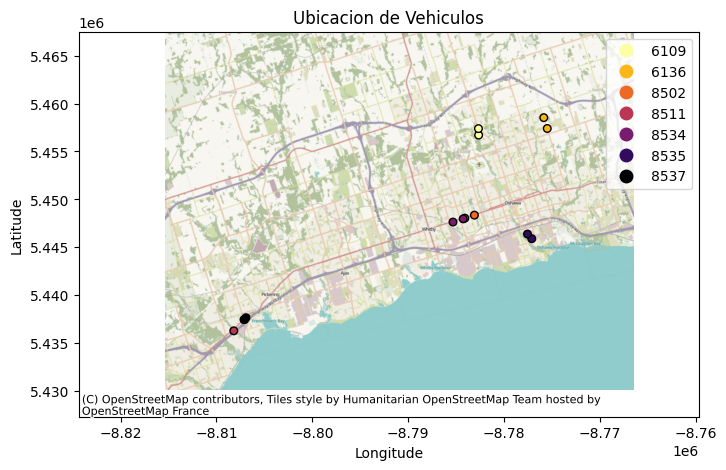

In [17]:
utils.plot_map([veh_pos_df, prev_pos_df], "longitude", "latitude",'vehicle_id', 'inferno_r', 'Ubicacion de Vehiculos')